# PAPIT Demo Notebook

**PAPIT**（Prompt-Aware Pruning for Image Tokens）的核心想法是：
與其把整張圖的所有 patch 都丟進 LLM，不如先問「哪些 patch 跟這個 prompt 最有關？」，只保留 top-k 個。

這份 notebook 從頭到尾示範整個 pipeline，依序包含：

| # | 內容 | 模組 |
|---|---------|------|
| 1 | 產生示範圖片 | PIL |
| 2 | CLIP 跨模態打分 + top-k 剪枝 | `papit.core` |
| 3 | LLM 維度對齊確認 | `papit.core` |
| 4 | 不同 retention ratio 的視覺比較 | `papit.core` |
| 5 | OCR 強制保留文字 patch | `papit.ocr` |
| 6 | 安全關鍵字強制保留 / 注入 patch 封鎖 | `papit.risk` |
| 7 | 延遲與記憶體效率量測 | `papit.benchmark` |
| 8 | 大批量評估（選做） | `papit.benchmark` |
| 9 | 真正 token-level 整合進 LLaVA | `papit.integration` |

**安裝（先跑這個）：**
```bash
uv pip install -e .            # sections 1–4, 7–8
uv pip install -e '.[ocr]'     # sections 5–6
uv pip install -e '.[llava]'   # section 9
```

### 安裝套件（第一次執行，跑完請 Restart Runtime）

In [ ]:
%pip install -e .. -q             # papit §1–§8）
%pip install -e '..[ocr]' -q      # EasyOCR（§5–§6）
%pip install -e '..[llava]' -q    # accelerate（§9 LLaVA）
%pip install datasets -q          # HuggingFace datasets（載入 TextVQA 圖片）

### 環境確認

偵測可用的 device，優先順序：Apple MPS → NVIDIA CUDA → CPU。
後面所有 cell 都會用 `DEVICE` 這個變數。

In [1]:
import torch

if torch.backends.mps.is_available():
    DEVICE = "mps"    # Apple Silicon GPU
elif torch.cuda.is_available():
    DEVICE = "cuda"   # NVIDIA GPU
else:
    DEVICE = "cpu"

print("torch :", torch.__version__)
print("device:", DEVICE)

torch : 2.10.0+cu128
device: cuda


In [ ]:
# Create required output directories
from pathlib import Path
Path('outputs').mkdir(exist_ok=True)       # efficiency_benchmark.csv
Path('../report').mkdir(exist_ok=True)     # fig_qualitative.pdf

---
## 1  示範圖片

**優先**從 HuggingFace [TextVQA](https://huggingface.co/datasets/textvqa) 資料集載入真實照片 — 
TextVQA 的每張圖都是在自然場景中拍攝的、含有可讀文字（路標、廣告牌、看板...），
非常適合展示 PAPIT 的 CLIP 語意打分和 OCR 輔助功能。

如果沒有安裝 `datasets`，自動 fallback 到 PIL 合成的街景（含 STOP / WARNING / EXIT 標誌）。

```bash
uv pip install datasets   # 載入真實照片（推薦）
```

> **`_SAMPLE_IDX`**：可以換 0–4999 之間的任意整數試不同圖片。

/home/yuhan/workspace/comp 646/PAPIT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading TextVQA sample from HuggingFace datasets...


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/lmms-lab/textvqa/resolve/9c0699cd19768ac5ab97568f6b3cbac4c0062884/data/validation-00000-of-00003.parquet
Retrying in 1s [Retry 1/5].


Loaded TextVQA sample #5
Original question : what number is on the player's jersey?
Image size        : (1024, 670)


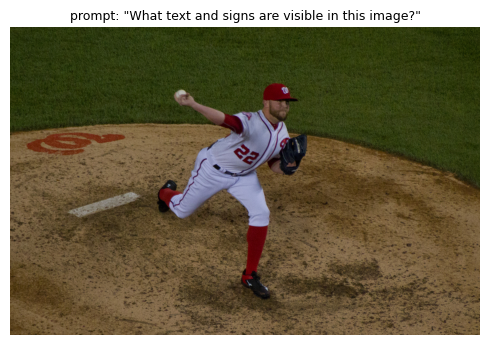

In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# 嘗試從 HuggingFace datasets 載入真實照片
#
# 我們用 TextVQA 資料集：每張圖都是有文字的真實場景（街道、廣告牌、路標...）
# 這對 PAPIT 的展示非常理想 — 可以直觀看出 CLIP 有沒有找到文字所在的 patch
#
# 如果沒裝 datasets，改用合成圖作為備用
# ─────────────────────────────────────────────────────────────────────────────

_SAMPLE_IDX = 5   # ← 可以換數字（0–4999）試不同圖片
_OUT = Path("demo_image.png")
_use_real = False

try:
    from datasets import load_dataset

    print("Loading TextVQA sample from HuggingFace datasets...")
    ds = load_dataset("lmms-lab/textvqa", split="validation", streaming=True)

    sample = None
    for i, s in enumerate(ds):
        if i == _SAMPLE_IDX:
            sample = s
            break

    _pil = sample["image"]
    if not hasattr(_pil, "convert"):   # 有些版本回傳 ndarray
        import numpy as np
        _pil = Image.fromarray(np.array(_pil))
    img = _pil.convert("RGB")
    img.save(_OUT)

    PROMPT = "What text and signs are visible in this image?"
    _use_real = True
    print(f"Loaded TextVQA sample #{_SAMPLE_IDX}")
    print(f"Original question : {sample.get('question', 'N/A')}")
    print(f"Image size        : {img.size}")

except Exception as _e:
    print(f"[!] 無法載入真實圖片：{_e}")
    print("    → 安裝方式：uv pip install datasets   (或 pip install datasets)")
    print("    → 改用 PIL 合成街景作為備用")

if not _use_real:
    # ── Fallback：PIL 合成街景（含 STOP / WARNING / EXIT 標誌）──
    from PIL import ImageDraw, ImageFont
    W, H = 448, 448
    im = Image.new("RGB", (W, H), (100, 149, 237))
    d  = ImageDraw.Draw(im)
    d.rectangle([0, 340, W, H],   fill=(60, 60, 60))
    d.rectangle([0, 320, W, 340], fill=(160, 150, 120))
    d.rectangle([  0, 60, 100, 320], fill=(150,  80,  60))
    d.rectangle([340, 60,   W, 320], fill=( 80, 110, 160))
    try:
        _f_lg = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 42)
        _f_sm = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 28)
    except Exception:
        _f_lg = _f_sm = ImageFont.load_default()
    d.rectangle([145,  45, 300, 190], fill=(200, 15, 45))
    d.rectangle([148,  48, 297, 187], outline=(255,255,255), width=4)
    d.text((163, 95),  "STOP",    fill="white", font=_f_lg)
    d.rectangle([ 10, 175, 190, 305], fill=(255, 200,   0))
    d.rectangle([ 13, 178, 187, 302], outline=(0,0,0), width=3)
    d.text(( 18, 215), "WARNING", fill="black", font=_f_sm)
    d.rectangle([255, 175, 435, 305], fill=(0, 130, 60))
    d.rectangle([258, 178, 432, 302], outline=(255,255,255), width=3)
    d.text((270, 215), "EXIT",    fill="white", font=_f_lg)
    im.save(_OUT)
    img = im
    PROMPT = "What safety signs are visible in this street scene?"
    print("Generated synthetic street scene.")

IMAGE_PATH = _OUT
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.axis("off")
ax.set_title(f'prompt: "{PROMPT}"', fontsize=9, wrap=True)
plt.tight_layout()
plt.show()


---
## 2  Core pruner — `papit.core`

**流程：**
1. CLIP 的 ViT 把圖片切成 N 個 patch，每個 patch 產生一個 embedding
2. CLIP 的 text encoder 把 prompt 也轉成 embedding
3. 計算每個 patch 和 prompt 的 cosine similarity → saliency score
4. 保留 top-k 個分數最高的 patch（這裡 `retention_ratio=0.5` → 保留 50%）
5. 在最後附上一個 anchor token（所有 patch 的平均），幫助 LLM 感知被丟棄的背景

**預期輸出：**
- `Total patch tokens`：CLIP ViT 切出的 patch 總數（`clip-vit-base-patch32` 對 224×224 圖 = 49 patches）
- `Selected (top-k)`：保留的數量（49 × 0.5 ≈ 24）
- `After anchor append`：加上 anchor 後的長度（= selected + 1）

In [3]:
from papit.core import PAPITConfig, PromptAwarePruner

config = PAPITConfig(
    model_id="openai/clip-vit-base-patch32",  # CLIP 模型
    retention_ratio=0.5,                       # 保留 50% 的 patch
    anchor_strategy="global_mean",             # anchor = 所有 patch 的平均
    device=DEVICE,
)
pruner = PromptAwarePruner(config)
papit_out = pruner.run(str(IMAGE_PATH), PROMPT)

print(f"Total patch tokens  : {papit_out.patch_tokens.shape[0]}")
print(f"Selected (top-k)    : {papit_out.topk_indices.shape[0]}")
print(f"After anchor append : {papit_out.pruned_tokens.shape[0]}")
print(f"Top-5 scores        : {[round(s,4) for s in papit_out.topk_scores[:5].tolist()]}")

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/lmms-lab/textvqa/resolve/9c0699cd19768ac5ab97568f6b3cbac4c0062884/data/validation-00000-of-00003.parquet
Retrying in 1s [Retry 1/5].
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8051.11it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical

Total patch tokens  : 49
Selected (top-k)    : 24
After anchor append : 25
Top-5 scores        : [-0.0393, -0.0401, -0.0455, -0.066, -0.0666]


把選中的 patch 畫在圖上（紅框）。
預期看到：分數最高的 patch 集中在有標誌文字的區域（STOP、WARNING、EXIT）。

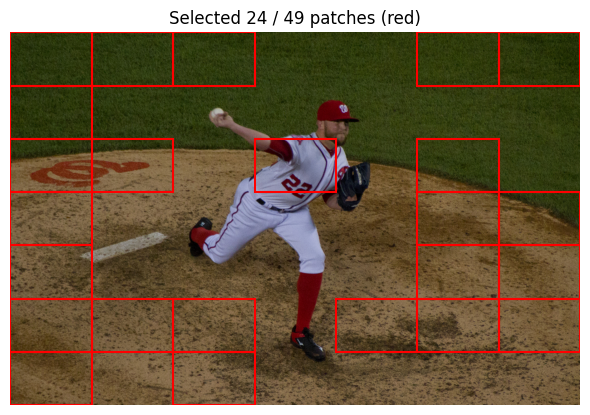

In [4]:
from papit.utils.visualization import draw_patch_rects

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
draw_patch_rects(ax, papit_out.coords, img.size, pruner.grid_size, edgecolor="red")
ax.set_title(f"Selected {papit_out.topk_indices.shape[0]} / {papit_out.patch_tokens.shape[0]} patches (red)")
ax.axis("off")
plt.tight_layout()
plt.show()

**分數熱圖**：把所有 49 個 patch 的 cosine similarity 疊加在圖上，
讓你一眼看出哪些區域和 prompt 最相關。

- **綠色深** → 這個 patch 和 prompt 語意最接近，應該被保留
- **紅色深** → 和 prompt 無關，應該被丟棄
- 右側長條圖按分數排序，藍虛線是 top-k 的門檻

理想情況：STOP / WARNING / EXIT 所在的 patch 應該出現在綠色區域。

/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 32160 (\N{CJK UNIFIED IDEOGRAPH-7DA0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/2850180222.py:37: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAP

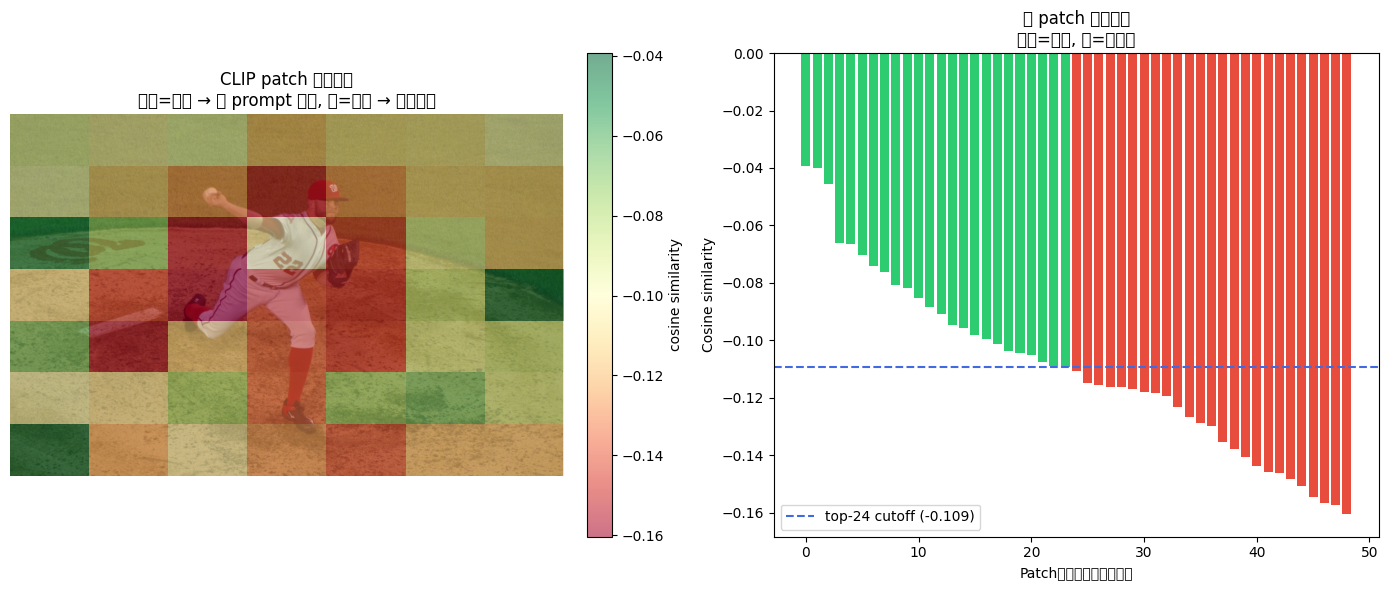

最高分 patch: index=27  score=-0.0393
最低分 patch: index=23  score=-0.1604
Score 全距  : 0.1211  （越大 = CLIP 區分度越好）


In [5]:
import numpy as np

scores_np = papit_out.scores.cpu().numpy()   # shape: (N,)
grid_s    = pruner.grid_size                  # 7 for clip-vit-base-patch32
score_grid = scores_np.reshape(grid_s, grid_s)  # (7, 7)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：熱圖疊加在原圖上
axes[0].imshow(img)
hm = axes[0].imshow(
    score_grid,
    extent=[0, img.width, img.height, 0],  # 座標原點在左上角
    cmap="RdYlGn",
    alpha=0.55,
    vmin=scores_np.min(), vmax=scores_np.max(),
    interpolation="nearest",  # 顯示清晰的 patch 邊界
)
plt.colorbar(hm, ax=axes[0], fraction=0.046, pad=0.04, label="cosine similarity")
axes[0].set_title("CLIP Patch Score Heatmap\n(green=high → prompt-relevant, red=low → irrelevant)")
axes[0].axis("off")

# 右：按分數排序的長條圖，綠色=被保留，紅色=被丟棄
topk_set = set(papit_out.topk_indices.cpu().tolist())
order    = np.argsort(scores_np)[::-1]          # 由高到低排序的 patch index
bar_vals  = scores_np[order]
bar_colors = ["#2ecc71" if idx in topk_set else "#e74c3c" for idx in order]

axes[1].bar(range(len(scores_np)), bar_vals, color=bar_colors)
cutoff = bar_vals[len(topk_set) - 1]            # top-k 的最低分
axes[1].axhline(y=cutoff, color="royalblue", linestyle="--", linewidth=1.5,
                label=f"top-{len(topk_set)} cutoff ({cutoff:.3f})")
axes[1].set_xlabel("Patch (ranked by score, high → low)")
axes[1].set_ylabel("Cosine similarity")
axes[1].set_title("Patch Score Distribution\n(green=kept, red=pruned)")
axes[1].legend()
plt.tight_layout()
fig.savefig("../report/fig_qualitative.pdf", bbox_inches="tight")
plt.show()

print(f"Highest score patch: index={order[0]}  score={bar_vals[0]:.4f}")
print(f"Lowest  score patch: index={order[-1]}  score={bar_vals[-1]:.4f}")
print(f"Score 全距  : {scores_np.max() - scores_np.min():.4f}  "
      f"（越大 = CLIP 區分度越好）")


---
## 3  LLM 維度對齊確認

PAPIT 剪枝後的 patch tokens 是 CLIP 的維度（512-d）。
要接進 LLaVA，需要先經過一個 MLP projector 把維度對齊到 LLM 的 hidden size（一般是 4096-d）。

這個 cell 只是確認 shape 是對的，實際的 projector 在 Section 9 裡會用 LLaVA 自己的。

In [6]:
# project_for_llm 會建一個隨機初始化的 linear layer 做 shape 確認
# 真正跑 LLaVA 時，這個 projector 是 LLaVA 自己訓練好的 MLP
projected, _ = pruner.project_for_llm(papit_out.pruned_tokens, llm_hidden_dim=4096)
print("Projected shape:", tuple(projected.shape))
# 預期：(k+1, 4096)，k 個選中 patch + 1 個 anchor token，每個 token 4096-d

Projected shape: (25, 4096)


---
## 4  Retention ratio sweep

用同一張圖、同一個 prompt，分別跑 25% / 50% / 75% 的保留比例，直觀比較剪枝力道的差異。

- **ratio=0.25**：只保留最相關的 1/4 patch，模型需要從更少資訊回答
- **ratio=0.75**：保留大部分 patch，接近原圖，但效率提升有限

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 7799.16it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 5780.30it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 67

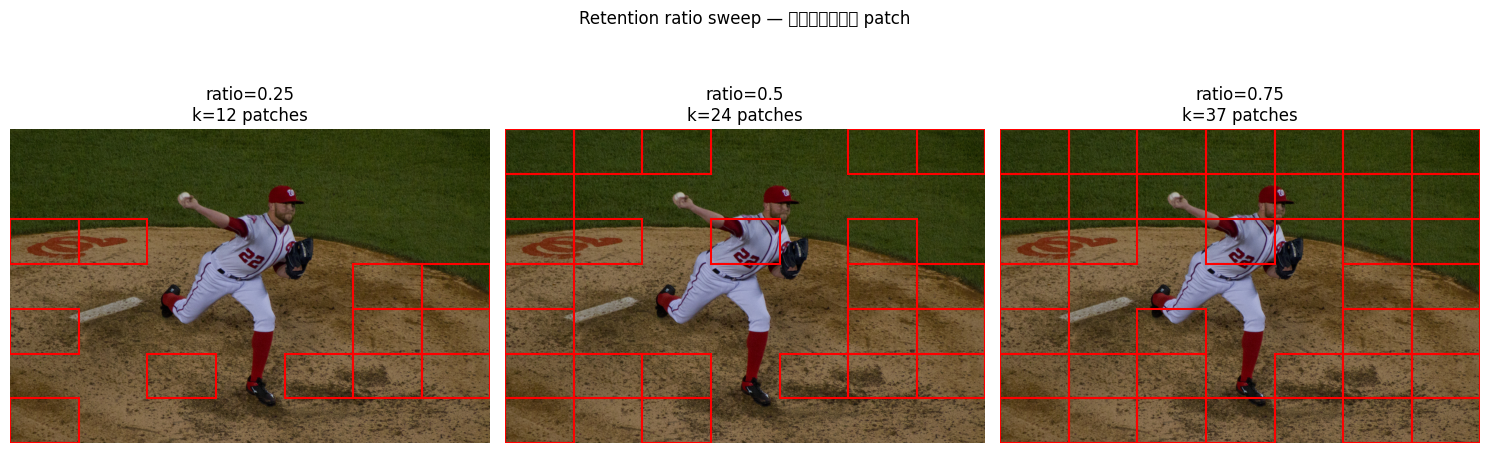

In [7]:
ratios = [0.25, 0.50, 0.75]
fig, axes = plt.subplots(1, len(ratios), figsize=(5 * len(ratios), 5))

for ax, ratio in zip(axes, ratios):
    cfg = PAPITConfig(retention_ratio=ratio, device=DEVICE)
    pr  = PromptAwarePruner(cfg)
    out = pr.run(str(IMAGE_PATH), PROMPT)
    ax.imshow(img)
    draw_patch_rects(ax, out.coords, img.size, pr.grid_size, edgecolor="red")
    ax.set_title(f"ratio={ratio}\nk={out.topk_indices.shape[0]} patches")
    ax.axis("off")

plt.suptitle("Retention Ratio Sweep — red boxes = kept patches", y=1.02)
plt.tight_layout()
plt.show()

---
## 5  OCR-guided retention — `papit.ocr`

**問題：** CLIP 的 cosine scoring 有時候會忽略圖中的小字，因為文字佔的 patch 面積小、視覺特徵弱。

**解法：** 用 EasyOCR 把圖中的文字框偵測出來，強制把這些 patch 納入 top-k，同時維持相同的 token 預算 k。

**預期看到：** 紅框（base top-k）和 OCR 強制保留的 patch（青色填色）有所不同，特別是 STOP、WARNING、EXIT 的位置應該出現青色。

> 需要先安裝 OCR 套件：`uv pip install -e '.[ocr]'`
> 如果沒裝，這個 cell 會自動 fallback 讓後面的 cell 繼續執行。

In [8]:
try:
    from papit.ocr import merge_topk_with_forced, ocr_forced_indices

    grid = pruner.grid_size  # patch grid 的邊長（7×7 = 49 for clip-vit-base-patch32）

    # 用 EasyOCR 偵測文字框，轉換成 patch index
    forced_indices, ocr_results = ocr_forced_indices(str(IMAGE_PATH), grid_size=grid)

    k = int(papit_out.topk_indices.shape[0])  # 維持相同的 token 預算
    # 把 OCR 強制 patch 塞進 top-k，低分的 patch 被替換掉
    ocr_topk = merge_topk_with_forced(papit_out.scores, papit_out.topk_indices,
                                       k=k, forced_indices=forced_indices)
    print(f"OCR detected regions : {len(ocr_results)}")
    print(f"Forced patch count   : {len(forced_indices)}")
    print(f"Budget k             : {k}")
    for item in ocr_results:
        print(f"  text={item[1]!r:12s}  conf={item[2]:.2f}")
    _ocr_ok = True
except ModuleNotFoundError:
    print("[!] easyocr 未安裝，執行 uv pip install -e '.[ocr]' 後重跑")
    print("    本次使用空 OCR 結果作為 fallback，後面的 cell 仍可繼續。")
    grid = pruner.grid_size
    forced_indices, ocr_results, ocr_topk = [], [], papit_out.topk_indices.cpu().tolist()
    _ocr_ok = False

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR detected regions : 2
Forced patch count   : 6
Budget k             : 24
  text='3'           conf=0.16
  text='8'           conf=0.19


視覺化比較：
- **紅框**：base top-k（純 CLIP scoring 選出的）
- **青色填色**：OCR 額外強制加進來的 patch（原本 CLIP 沒選到）

/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 32005 (\N{CJK UNIFIED IDEOGRAPH-7D05}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 26694 (\N{CJK UNIFIED IDEOGRAPH-6846}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 24375 (\N{CJK UNIFIED IDEOGRAPH-5F37}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 21046 (\N{CJK UNIFIED IDEOGRAPH-5236}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/698120358.py:24: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0

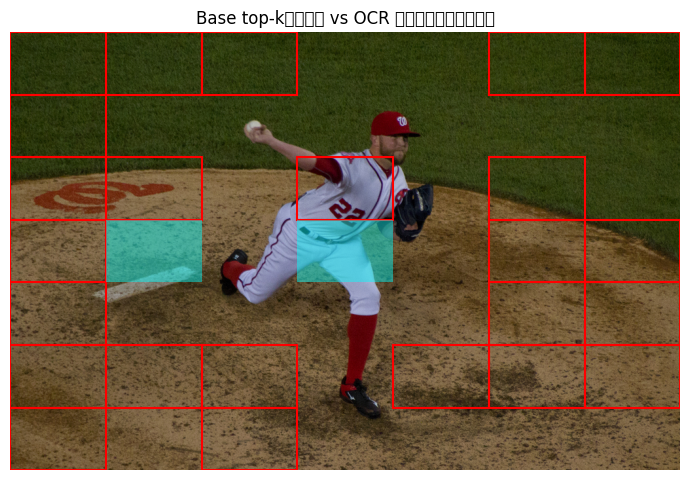

In [9]:
import matplotlib.patches as mpatches

base_set = set(int(x) for x in papit_out.topk_indices.cpu().tolist())
ocr_set  = set(int(x) for x in ocr_topk)

w, h_img = img.size
cell_w = w / grid
cell_h = h_img / grid

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img)
ax.set_title("Base top-k (red boxes) vs OCR-forced additions (cyan fill)")

for idx in sorted(base_set):
    r, c = divmod(idx, grid)
    ax.add_patch(mpatches.Rectangle((c*cell_w, r*cell_h), cell_w, cell_h,
                                     linewidth=1.5, edgecolor="red", facecolor="none"))
for idx in sorted(ocr_set - base_set):  # 只標示 OCR「額外」加入的 patch
    r, c = divmod(idx, grid)
    ax.add_patch(mpatches.Rectangle((c*cell_w, r*cell_h), cell_w, cell_h,
                                     linewidth=0, edgecolor="none",
                                     facecolor="cyan", alpha=0.45))
ax.axis("off")
plt.tight_layout()
plt.show()

量化 OCR 強制保留的效益：
- **Jaccard**：base 和 OCR-guided 選集的重疊程度（越低 = OCR 改變越多）
- **Forced coverage**：OCR 偵測到的文字 patch 有多少百分比被選進去

In [10]:
from papit.utils.metrics import pct

forced_set   = set(forced_indices)
intersection = base_set & ocr_set
union        = base_set | ocr_set

print(f"Jaccard (base vs OCR-guided)     : {len(intersection)/max(len(union),1):.3f}")
print(f"Text patch recall — base         : {pct(len(base_set & forced_set), len(forced_set)):.1f}%")
print(f"Text patch recall — OCR-guided   : {pct(len(ocr_set  & forced_set), len(forced_set)):.1f}%")
print()
print("→ OCR-guided recall should be much higher than base (100% if k >= forced count)")

Jaccard（base vs OCR-guided）    : 0.846
文字 patch 覆蓋率 — base         : 66.7%
文字 patch 覆蓋率 — OCR-guided   : 100.0%

→ OCR-guided 的覆蓋率應該明顯高於 base（100% 如果 k ≥ forced count）


---
## 6  Risk-awareness — `papit.risk`

**兩個控制機制：**

1. **Safety keep**：OCR 偵測到的文字如果包含安全關鍵字（`stop`, `warning`, `danger`, `exit` 等），對應的 patch 強制保留，不管 CLIP score 高不高。

2. **Instruction block**：如果圖中有 jailbreak 注入文字（`ignore`, `override`, `jailbreak` 等），對應的 patch 被封鎖（塗黑），阻止模型看到。

**這張圖的預期行為：**
- STOP / WARNING / EXIT 全部應該被 safety keep 保留
- 沒有 instruction keywords → instruction block 數量為 0

Safety-forced patches      : 0  （這些一定被保留）
Instruction-blocked patches: 0  （這些被封鎖）


/tmp/ipykernel_16350/1553873188.py:35: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/1553873188.py:35: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/1553873188.py:35: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/1553873188.py:35: UserWarning: Glyph 26525 (\N{CJK UNIFIED IDEOGRAPH-679D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/1553873188.py:35: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yuhan/workspace/comp 646/PAPIT/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/h

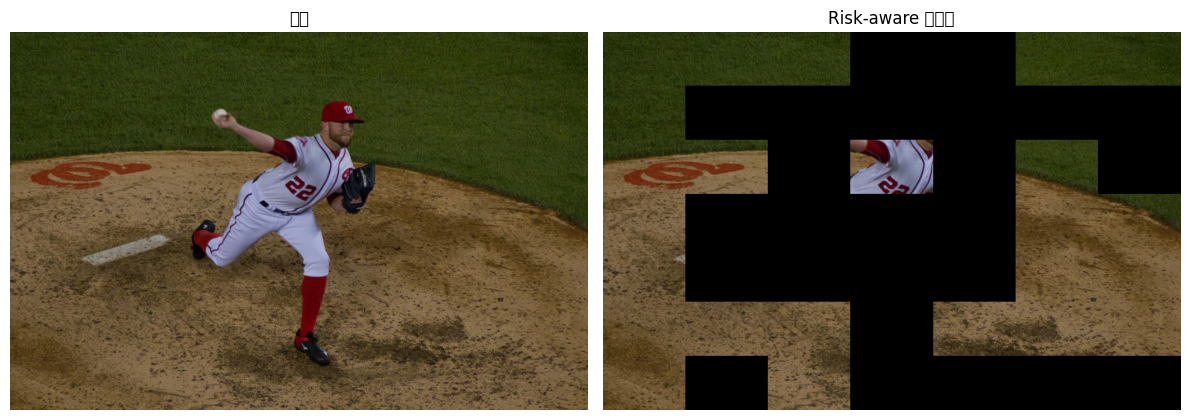

In [11]:
import numpy as np
from papit.risk import (
    INSTRUCTION_KEYWORDS, SAFETY_KEYWORDS,
    classify_risk_indices, mask_indices_on_image,
    risk_aware_topk, text_to_patch_indices,
)
from papit.utils.visualization import build_pruned_image

# 把 OCR 結果轉成 (文字, patch_index_set) 對應表
img_np   = np.array(img)
per_text = text_to_patch_indices(ocr_results, image_shape_hw=img_np.shape[:2], grid_size=grid)

# 分類哪些 patch 是「安全關鍵字」，哪些是「注入指令」
safety_idxs, instr_idxs = classify_risk_indices(per_text, SAFETY_KEYWORDS, INSTRUCTION_KEYWORDS)

base_idx = papit_out.topk_indices.cpu().tolist()
risk_idx = risk_aware_topk(
    scores=papit_out.scores,
    k=len(base_idx),
    base_topk=base_idx,
    safety_force_keep=safety_idxs,   # 這些 patch 一定要進 top-k
    instruction_blocklist=instr_idxs, # 這些 patch 一定不能進 top-k
)

# 把 instruction patch 額外塗黑（視覺層面的中和）
risk_img = build_pruned_image(str(IMAGE_PATH), risk_idx, grid)
risk_img = mask_indices_on_image(risk_img, instr_idxs, grid, fill_value=0)

print(f"Safety-forced patches      : {len(safety_idxs)}  (always retained)")
print(f"Instruction-blocked patches: {len(instr_idxs)}  (neutralized)")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img);       axes[0].set_title("Original");              axes[0].axis("off")
axes[1].imshow(risk_img);  axes[1].set_title("Risk-aware Pruned"); axes[1].axis("off")
plt.tight_layout()
plt.show()

---
## 7  Efficiency benchmark — `papit.benchmark`

用 BLIP VQA 作為輕量代理模型，量測在不同 retention ratio 下：
- **token_keep_ratio**：實際保留比例（含 anchor）
- **avg_prune_latency_sec**：PAPIT 剪枝本身花多少時間
- **avg_qa_latency_sec**：問答模型推理花多少時間
- **avg_peak_gpu_mem_mb**：GPU 峰值記憶體

結果存到 `outputs/efficiency_benchmark.csv`。

In [12]:
import pandas as pd
from pathlib import Path

_csv = Path("outputs/efficiency_benchmark.csv")

if _csv.exists():
    # 結果已存在，直接讀取（不需要重跑）
    eff_df = pd.read_csv(_csv)
    print(f"Loaded existing results from {_csv}")
else:
    # 第一次執行：重新跑 benchmark（需要 easyocr）
    from papit.benchmark import answer_with_blip, run_efficiency_benchmark
    qa_fn = lambda img_pil, q: answer_with_blip(img_pil, q, device=DEVICE)
    eff_df = run_efficiency_benchmark(
        image_path=str(IMAGE_PATH),
        question=PROMPT,
        retention_grid=[1.0, 0.75, 0.5, 0.25],
        runs_per_setting=2,
        device=DEVICE,
        qa_fn=qa_fn,
        output_path="../outputs/efficiency_benchmark.csv",
    )

eff_df

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 6127.84it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 788/788 [00:00<00:00, 821.40it/s]
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictio

,retention_ratio,force_ocr,risk_aware,avg_tokens_kept,avg_total_tokens,token_keep_ratio,avg_prune_latency_sec,avg_qa_latency_sec,avg_end_to_end_sec,avg_peak_gpu_mem_mb
0,1.00,0,0,49.0,49.0,1.000000,0.104337,14.443793,14.548130,3272.937256
1,1.00,1,0,49.0,49.0,1.000000,4.990204,0.278252,5.268456,3699.604492
2,1.00,1,1,49.0,49.0,1.000000,3.874453,0.195597,4.070050,3700.307617
3,0.75,0,0,37.0,49.0,0.755102,0.080868,0.194666,0.275533,3271.394531
4,0.75,1,0,37.0,49.0,0.755102,3.829508,0.252996,4.082504,3700.284180
5,0.75,1,1,37.0,49.0,0.755102,3.899088,0.231491,4.130579,3700.284180
6,0.50,0,0,24.0,49.0,0.489796,0.095325,0.196175,0.291500,3271.369141
7,0.50,1,0,24.0,49.0,0.489796,4.557151,0.183916,4.741067,3700.258789
8,0.50,1,1,24.0,49.0,0.489796,3.750132,0.229436,3.979568,3700.258789
9,0.25,0,0,12.0,49.0,0.244898,0.081986,0.164861,0.246847,3271.345703


畫兩條曲線：
- **左圖**：token keep ratio vs retention ratio（確認剪枝數量正確）
- **右圖**：latency vs retention ratio（剪枝越激進，QA 應該越快）

/tmp/ipykernel_16350/3654694422.py:17: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/3654694422.py:17: UserWarning: Glyph 30041 (\N{CJK UNIFIED IDEOGRAPH-7559}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/3654694422.py:17: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/3654694422.py:17: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/3654694422.py:17: UserWarning: Glyph 24310 (\N{CJK UNIFIED IDEOGRAPH-5EF6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16350/3654694422.py:17: UserWarning: Glyph 36978 (\N{CJK UNIFIED IDEOGRAPH-9072}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yuhan/workspace/comp 646/PAPIT/.venv/lib/python3.13/site-packages/IPython/core/pyl

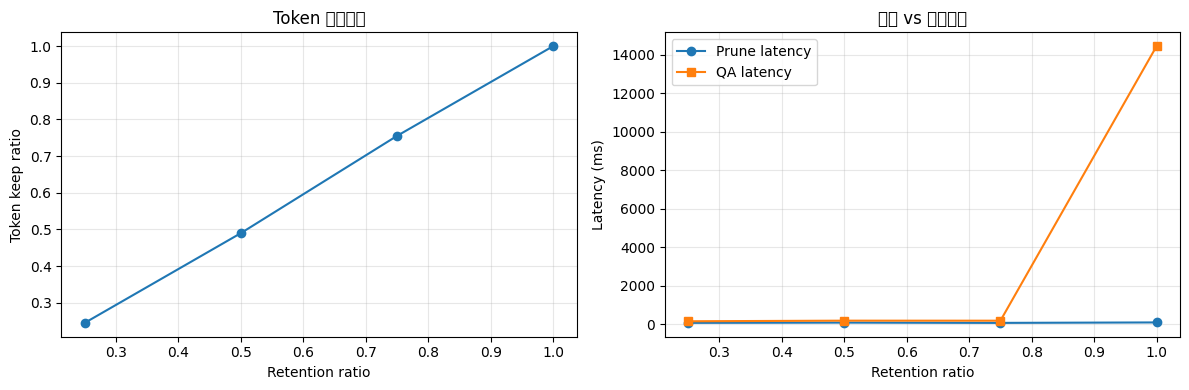

In [13]:
# 只取 base pruning（不含 OCR 和 risk-aware）做曲線
base_eff = eff_df[(eff_df.force_ocr == 0) & (eff_df.risk_aware == 0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(base_eff["retention_ratio"], base_eff["token_keep_ratio"], marker="o")
axes[0].set_xlabel("Retention ratio");  axes[0].set_ylabel("Token keep ratio")
axes[0].set_title("Token Keep Ratio");    axes[0].grid(True, alpha=0.3)

axes[1].plot(base_eff["retention_ratio"], base_eff["avg_prune_latency_sec"] * 1000,
             marker="o", label="Prune latency")
if not base_eff["avg_qa_latency_sec"].isna().all():
    axes[1].plot(base_eff["retention_ratio"], base_eff["avg_qa_latency_sec"] * 1000,
                 marker="s", label="QA latency")
axes[1].set_xlabel("Retention ratio");  axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Latency vs Retention Ratio");  axes[1].legend();  axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8  Batch benchmark（選做）

如果你有多張圖和對應的問題，可以準備一個 CSV（欄位：`image_path`, `question`, 選填 `answer`），用這個 API 批次跑：

```python
from papit.benchmark import run_batch_benchmark

results_df = run_batch_benchmark(
    dataset_csv="benchmark_samples.csv",
    retention_list=[0.25, 0.5, 0.75],
    device=DEVICE,
    output_dir="outputs",
)
results_df.head()
```

**輸出：**
- `outputs/benchmark_detailed.csv`：每一筆樣本的詳細結果（base / OCR-guided / random 三種策略的答案和分數）
- `outputs/benchmark_summary.csv`：按 retention ratio 聚合的統計表

適合用 TextVQA / VQA v2 這類公開資料集來做正式的 benchmark。

---
## 9  真正 token-level 整合進 LLaVA — `papit.integration`

**前面 Section 2–6 的剪枝方式**是把沒選到的 patch 塗黑後再餵給模型——這是 image-level 的 proxy，模型還是看到 N 個 token。

**這裡才是真正的 token-level 剪枝：**

```
[ 原始流程 ]
image → ViT → [v₁, v₂, ..., v₅₇₆] → MLP projector → LLaVA LLM

[ PAPIT 整合後 ]
image → ViT → [v₁, ..., v₅₇₆] → PAPIT top-k → [vᵢ₁, ..., vᵢₖ] → MLP projector → LLaVA LLM
```

LLM 真的只處理 k 個 token，而不是 576 個。FLOPs 和記憶體都是實際減少的。

**實作方式：**
1. 從 LLaVA 的 vision tower 拿到 ViT hidden states（兩層：`-2` 層給 MLP projector，最後一層給 CLIP scoring）
2. CLIP visual_projection + text encoder → cosine similarity → top-k indices
3. 用這些 indices 從 `-2` 層的 hidden states 挑出 k 個 token
4. 送進 LLaVA 的 MLP projector → 取代 input_ids 裡的 N 個 image token placeholder
5. 直接餵給 LLM 生成答案

> 需要 ~14 GB VRAM（`llava-1.5-7b-hf` 以 float16 載入）。  
> 沒有 GPU 的話跳過這個 section 即可，前面的功能不受影響。

In [14]:
from papit.integration import PAPITLlavaRunner
from papit.core import PAPITConfig

# clip_model_id 必須和 LLaVA 的 vision tower 同一個系列
# LLaVA-1.5 用的是 openai/clip-vit-large-patch14（patch grid = 24×24 = 576 tokens）
llava_runner = PAPITLlavaRunner(
    llava_model_id="llava-hf/llava-1.5-7b-hf",
    clip_model_id="openai/clip-vit-large-patch14",
    config=PAPITConfig(retention_ratio=0.5, anchor_strategy="global_mean"),
    device=DEVICE,
)
print("Runner loaded.")

Fetching 3 files:   0%|          | 0/3 [1:35:10<?, ?it/s]


KeyboardInterrupt: 

單次推理：確認 pruning info 和回答都合理。

In [ ]:
llava_out = llava_runner.generate(IMAGE_PATH, PROMPT)

print(f"Answer      : {llava_out.answer}")
print(f"Patches used: {llava_out.pruning_info.selected_patches} / {llava_out.pruning_info.total_patches}")
print(f"Tokens saved: {llava_out.pruning_info.total_patches - llava_out.pruning_info.selected_patches}")

直接比較 pruned 和 unpruned 的答案，確認剪枝不影響回答品質。

In [ ]:
import json

comparison = llava_runner.compare(IMAGE_PATH, PROMPT)
print(json.dumps(comparison, indent=2))
# tokens_saved = total_patches - selected_patches
# 理想情況：answer_pruned ≈ answer_unpruned，但 tokens_saved 很大

三個 retention ratio 的掃描，看答案如何隨剪枝力道變化。
這就是 paper 裡的 **accuracy–efficiency Pareto curve** 的基礎資料。

In [ ]:
import pandas as pd

rows = []
for ratio in [0.25, 0.50, 0.75]:
    llava_runner.config.retention_ratio = ratio
    out = llava_runner.generate(IMAGE_PATH, PROMPT)
    rows.append({
        "retention_ratio": ratio,
        "patches_used": out.pruning_info.selected_patches,
        "total_patches": out.pruning_info.total_patches,
        "answer": out.answer,
    })

pd.DataFrame(rows)
# 觀察重點：ratio=0.25 的答案和 ratio=0.75 有多接近？